# PRM Benchmarking Plotting Tools

Tools for visualizing MatSAT solver performance across different blocking percentages.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Optional

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Configuration
CSV_DIR = Path("trace-artifacts/csv")

# Available statistics columns in the CSV files
AVAILABLE_STATS = [
    "jsat",          # J_SAT objective value
    "grad_sq",       # Squared gradient
    "epsilon",       # Learning rate parameter
    "alpha",         # Step size
    "err",           # Error
    "unsat_clauses", # Number of unsatisfied clauses
]

# Pretty names for plotting
STAT_LABELS = {
    "jsat": "J_SAT (Objective)",
    "grad_sq": "Gradient Squared",
    "epsilon": "Epsilon",
    "alpha": "Alpha (Step Size)",
    "err": "Error",
    "unsat_clauses": "Unsatisfied Clauses",
}

# Color palette for different percentages
PERCENT_COLORS = {
    0: "#2ecc71",    # Green - no blocking
    25: "#3498db",   # Blue
    50: "#f39c12",   # Orange
    75: "#e74c3c",   # Red
    100: "#9b59b6",  # Purple - all blocked except path
}

In [3]:
def load_prm_csvs(
    base_name: str,
    percentages: List[int] = [0, 25, 50, 75, 100],
    csv_dir: Path = CSV_DIR,
) -> dict:
    """
    Load CSV files for different blocking percentages.
    
    Args:
        base_name: Base name without percentage, e.g., "prm_5v_6e_blocked"
        percentages: List of percentages to load
        csv_dir: Directory containing CSV files
        
    Returns:
        Dictionary mapping percentage -> DataFrame
    """
    data = {}
    for pct in percentages:
        filename = f"matsat_{base_name}_{pct}pct.csv"
        filepath = csv_dir / filename
        if filepath.exists():
            df = pd.read_csv(filepath)
            data[pct] = df
            print(f"✓ Loaded {filename}: {len(df)} rows")
        else:
            print(f"✗ Not found: {filename}")
    return data


def list_available_prm_tests(csv_dir: Path = CSV_DIR) -> List[str]:
    """List available PRM test base names."""
    files = list(csv_dir.glob("matsat_prm_*_blocked_*.csv"))
    base_names = set()
    for f in files:
        # Extract base name by removing matsat_ prefix and _Xpct.csv suffix
        name = f.stem.replace("matsat_", "")
        # Remove the percentage suffix
        for pct in ["_0pct", "_25pct", "_50pct", "_75pct", "_100pct"]:
            name = name.replace(pct, "")
        base_names.add(name)
    return sorted(base_names)

In [4]:
def plot_stat_overlay(
    data: dict,
    stat: str,
    title: Optional[str] = None,
    try_idx: int = 0,
    log_scale: bool = False,
    figsize: tuple = (12, 6),
):
    """
    Plot a statistic across all blocking percentages on the same graph.
    
    Args:
        data: Dictionary from load_prm_csvs
        stat: Column name to plot (e.g., 'jsat', 'unsat_clauses')
        title: Optional custom title
        try_idx: Which try to plot (default 0)
        log_scale: Whether to use log scale for y-axis
        figsize: Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    for pct, df in sorted(data.items()):
        try_data = df[df["try_idx"] == try_idx]
        if len(try_data) == 0:
            continue
        
        color = PERCENT_COLORS.get(pct, "gray")
        ax.plot(
            try_data["iter_idx"],
            try_data[stat],
            label=f"{pct}% blocked",
            color=color,
            linewidth=2,
            alpha=0.8,
        )
    
    ax.set_xlabel("Iteration")
    ax.set_ylabel(STAT_LABELS.get(stat, stat))
    
    if log_scale:
        ax.set_yscale("log")
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"{STAT_LABELS.get(stat, stat)} vs Iteration (Try {try_idx})")
    
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

In [5]:
def plot_multiple_stats(
    data: dict,
    stats: List[str],
    try_idx: int = 0,
    figsize: tuple = (14, 10),
):
    """
    Plot multiple statistics in subplots.
    
    Args:
        data: Dictionary from load_prm_csvs
        stats: List of column names to plot
        try_idx: Which try to plot
        figsize: Figure size
    """
    n_stats = len(stats)
    n_cols = 2
    n_rows = (n_stats + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_stats > 1 else [axes]
    
    for idx, stat in enumerate(stats):
        ax = axes[idx]
        
        for pct, df in sorted(data.items()):
            try_data = df[df["try_idx"] == try_idx]
            if len(try_data) == 0:
                continue
            
            color = PERCENT_COLORS.get(pct, "gray")
            ax.plot(
                try_data["iter_idx"],
                try_data[stat],
                label=f"{pct}%",
                color=color,
                linewidth=2,
                alpha=0.8,
            )
        
        ax.set_xlabel("Iteration")
        ax.set_ylabel(STAT_LABELS.get(stat, stat))
        ax.set_title(STAT_LABELS.get(stat, stat))
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f"MatSAT Statistics (Try {try_idx})", fontsize=14, y=1.02)
    plt.tight_layout()
    return fig, axes

In [6]:
def plot_convergence_comparison(
    data: dict,
    stat: str = "unsat_clauses",
    threshold: float = 0.0,
    figsize: tuple = (10, 6),
):
    """
    Compare convergence speed across blocking percentages.
    Shows iterations to reach threshold.
    
    Args:
        data: Dictionary from load_prm_csvs
        stat: Statistic to check for convergence
        threshold: Value to consider as "converged"
        figsize: Figure size
    """
    convergence_iters = {}
    
    for pct, df in data.items():
        try_data = df[df["try_idx"] == 0]
        converged = try_data[try_data[stat] <= threshold]
        if len(converged) > 0:
            convergence_iters[pct] = converged["iter_idx"].iloc[0]
        else:
            convergence_iters[pct] = len(try_data)  # Didn't converge
    
    fig, ax = plt.subplots(figsize=figsize)
    
    percentages = sorted(convergence_iters.keys())
    iters = [convergence_iters[p] for p in percentages]
    colors = [PERCENT_COLORS.get(p, "gray") for p in percentages]
    
    bars = ax.bar(
        [f"{p}%" for p in percentages],
        iters,
        color=colors,
        edgecolor="black",
        linewidth=1.5,
    )
    
    ax.set_xlabel("Blocking Percentage")
    ax.set_ylabel(f"Iterations to {STAT_LABELS.get(stat, stat)} ≤ {threshold}")
    ax.set_title("Convergence Speed Comparison")
    
    # Add value labels on bars
    for bar, val in zip(bars, iters):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(val),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )
    
    plt.tight_layout()
    return fig, ax


def find_best_try(df: pd.DataFrame) -> int:
    """
    Find the best try index for a DataFrame.
    
    Returns the FIRST try that reaches 0 unsatisfied clauses.
    If no try reaches 0, returns the try with the minimum final unsat_clauses.
    """
    tries = df["try_idx"].unique()
    
    # First, look for tries that reach 0 unsat_clauses
    for try_idx in sorted(tries):
        try_data = df[df["try_idx"] == try_idx]
        if try_data["unsat_clauses"].min() == 0:
            return try_idx
    
    # No try reached 0, find the one with minimum final unsat_clauses
    best_try = tries[0]
    best_min = float("inf")
    
    for try_idx in tries:
        try_data = df[df["try_idx"] == try_idx]
        min_unsat = try_data["unsat_clauses"].min()
        if min_unsat < best_min:
            best_min = min_unsat
            best_try = try_idx
    
    return best_try


def plot_stat_overlay_best_try(
    data: dict,
    stat: str,
    title: Optional[str] = None,
    log_scale: bool = False,
    figsize: tuple = (12, 6),
):
    """
    Plot a statistic using the BEST try for each percentage.
    
    Best try = first try to reach 0 unsat_clauses, or the try with minimum unsat_clauses.
    
    Args:
        data: Dictionary from load_prm_csvs
        stat: Column name to plot (e.g., 'jsat', 'unsat_clauses')
        title: Optional custom title
        log_scale: Whether to use log scale for y-axis
        figsize: Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    for pct, df in sorted(data.items()):
        best_try = find_best_try(df)
        try_data = df[df["try_idx"] == best_try]
        
        if len(try_data) == 0:
            continue
        
        color = PERCENT_COLORS.get(pct, "gray")
        reached_zero = try_data["unsat_clauses"].min() == 0
        label = f"{pct}% (try {best_try}{'✓' if reached_zero else ''})"
        
        ax.plot(
            try_data["iter_idx"],
            try_data[stat],
            label=label,
            color=color,
            linewidth=2,
            alpha=0.8,
        )
    
    ax.set_xlabel("Iteration")
    ax.set_ylabel(STAT_LABELS.get(stat, stat))
    
    if log_scale:
        ax.set_yscale("log")
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"{STAT_LABELS.get(stat, stat)} - Best Try per Percentage")
    
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax


def plot_multiple_stats_best_try(
    data: dict,
    stats: List[str],
    figsize: tuple = (14, 10),
):
    """
    Plot multiple statistics using the BEST try for each percentage.
    
    Args:
        data: Dictionary from load_prm_csvs
        stats: List of column names to plot
        figsize: Figure size
    """
    # Pre-compute best tries for each percentage
    best_tries = {pct: find_best_try(df) for pct, df in data.items()}
    
    n_stats = len(stats)
    n_cols = 2
    n_rows = (n_stats + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_stats > 1 else [axes]
    
    for idx, stat in enumerate(stats):
        ax = axes[idx]
        
        for pct, df in sorted(data.items()):
            best_try = best_tries[pct]
            try_data = df[df["try_idx"] == best_try]
            
            if len(try_data) == 0:
                continue
            
            color = PERCENT_COLORS.get(pct, "gray")
            reached_zero = try_data["unsat_clauses"].min() == 0
            label = f"{pct}%{'✓' if reached_zero else ''}"
            
            ax.plot(
                try_data["iter_idx"],
                try_data[stat],
                label=label,
                color=color,
                linewidth=2,
                alpha=0.8,
            )
        
        ax.set_xlabel("Iteration")
        ax.set_ylabel(STAT_LABELS.get(stat, stat))
        ax.set_title(STAT_LABELS.get(stat, stat))
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("MatSAT Statistics - Best Try per Percentage", fontsize=14, y=1.02)
    plt.tight_layout()
    return fig, axes


def summarize_best_tries(data: dict):
    """
    Print a summary of the best try for each percentage.
    """
    print("Best try summary:")
    print("-" * 60)
    for pct, df in sorted(data.items()):
        best_try = find_best_try(df)
        try_data = df[df["try_idx"] == best_try]
        min_unsat = try_data["unsat_clauses"].min()
        iter_to_zero = None
        if min_unsat == 0:
            iter_to_zero = try_data[try_data["unsat_clauses"] == 0]["iter_idx"].iloc[0]
        
        status = f"✓ reached 0 at iter {iter_to_zero}" if min_unsat == 0 else f"✗ min={int(min_unsat)}"
        print(f"  {pct:>3}% blocked: try {best_try} - {status}")
    print("-" * 60)

---
## Usage Examples

In [7]:
# List available PRM tests
print("Available PRM tests:")
for name in list_available_prm_tests():
    print(f"  - {name}")

Available PRM tests:
  - prm_5v_6e_blocked
  - prm_6v_7e_blocked
  - prm_7v_13e_blocked


In [8]:
# Load data for 5-node graph
data_5v = load_prm_csvs("prm_5v_6e_blocked")

✓ Loaded matsat_prm_5v_6e_blocked_0pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_25pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_50pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_75pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_100pct.csv: 250 rows


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '5-Node Graph: J_SAT Convergence'}, xlabel='Iteration', ylabel='J_SAT (Objective)'>)

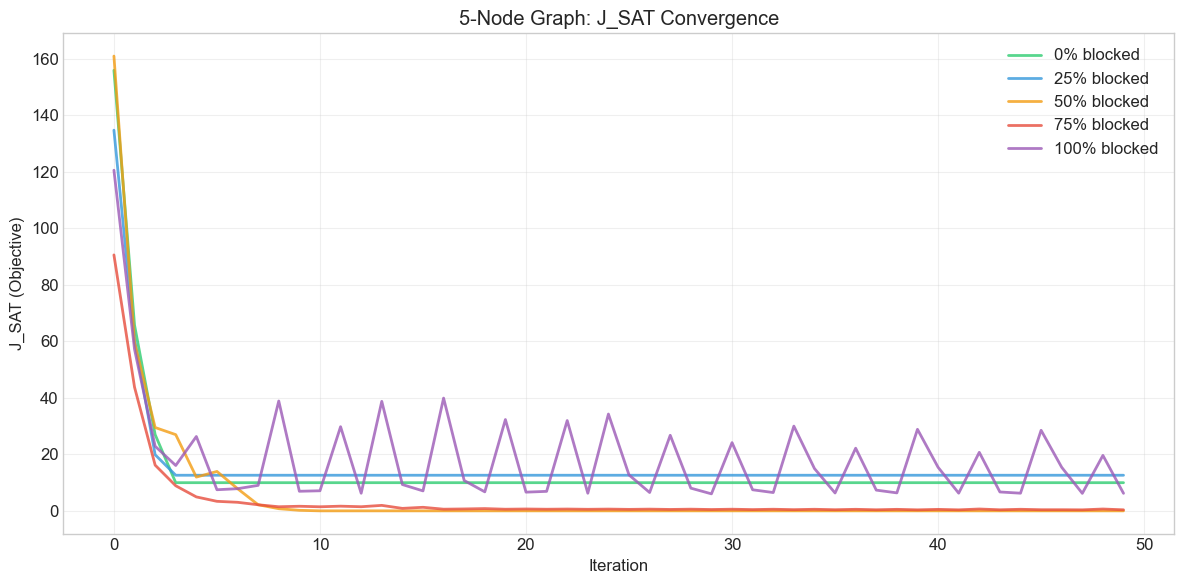

In [9]:
# Plot J_SAT overlay
plot_stat_overlay(data_5v, "jsat", title="5-Node Graph: J_SAT Convergence")

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '5-Node Graph: Unsatisfied Clauses'}, xlabel='Iteration', ylabel='Unsatisfied Clauses'>)

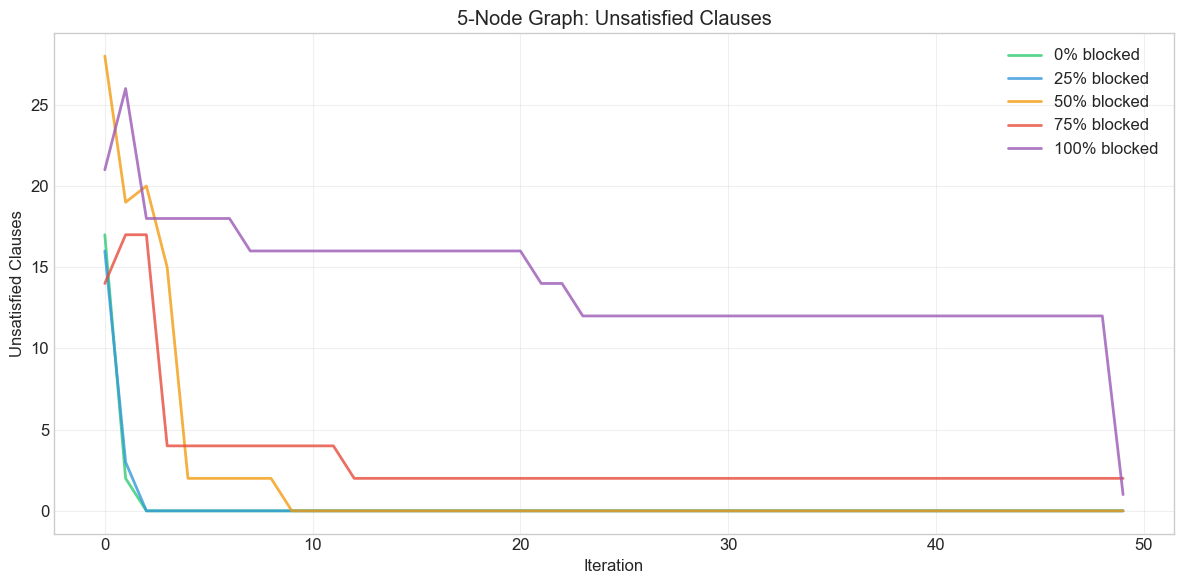

In [10]:
# Plot unsatisfied clauses
plot_stat_overlay(data_5v, "unsat_clauses", title="5-Node Graph: Unsatisfied Clauses")

(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'J_SAT (Objective)'}, xlabel='Iteration', ylabel='J_SAT (Objective)'>,
        <Axes: title={'center': 'Unsatisfied Clauses'}, xlabel='Iteration', ylabel='Unsatisfied Clauses'>,
        <Axes: title={'center': 'Gradient Squared'}, xlabel='Iteration', ylabel='Gradient Squared'>,
        <Axes: title={'center': 'Alpha (Step Size)'}, xlabel='Iteration', ylabel='Alpha (Step Size)'>],
       dtype=object))

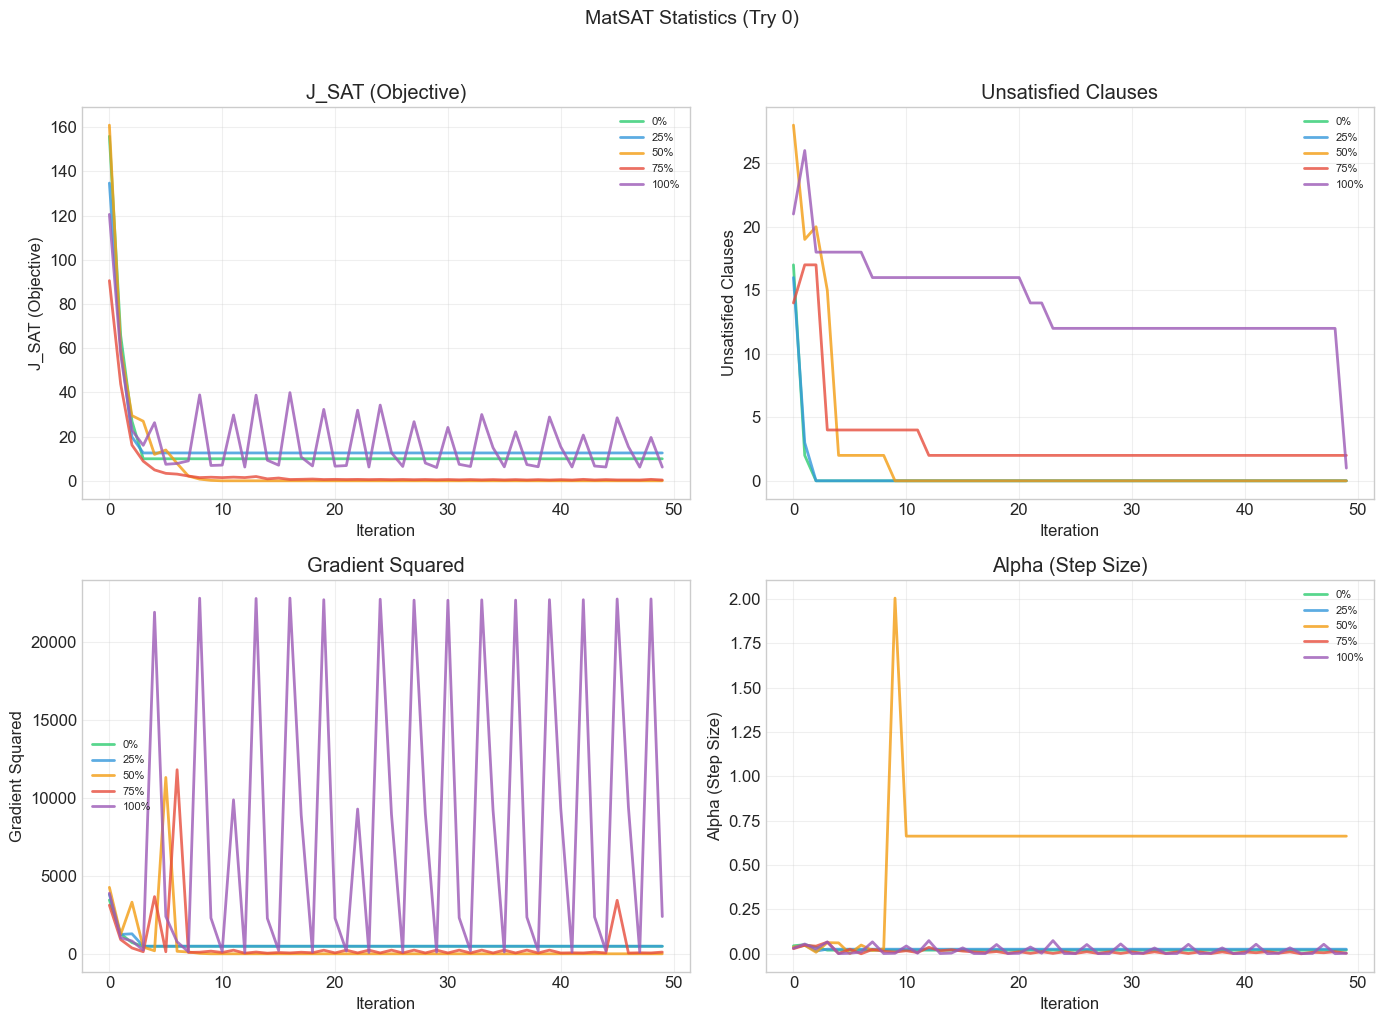

In [11]:
# Plot multiple stats at once
plot_multiple_stats(data_5v, ["jsat", "unsat_clauses", "grad_sq", "alpha"])

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Convergence Speed Comparison'}, xlabel='Blocking Percentage', ylabel='Iterations to Unsatisfied Clauses ≤ 0.0'>)

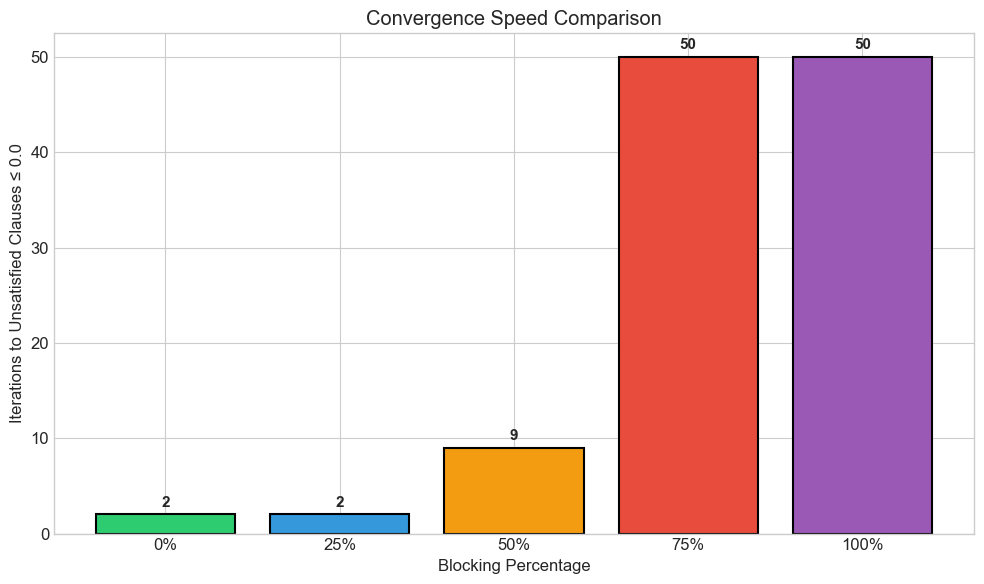

In [12]:
# Compare convergence speed
plot_convergence_comparison(data_5v, stat="unsat_clauses", threshold=0.0)

In [13]:
# Summary of best tries for each percentage
summarize_best_tries(data_5v)

Best try summary:
------------------------------------------------------------
    0% blocked: try 0 - ✓ reached 0 at iter 2
   25% blocked: try 0 - ✓ reached 0 at iter 2
   50% blocked: try 0 - ✓ reached 0 at iter 9
   75% blocked: try 0 - ✗ min=2
  100% blocked: try 0 - ✗ min=1
------------------------------------------------------------


/var/folders/30/nqp_2f3d38g7cj28w_nf1rhm0000gn/T/ipykernel_65846/1841775070.py:145: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '5-Node Graph: J_SAT (Best Try)'}, xlabel='Iteration', ylabel='J_SAT (Objective)'>)

/Users/joshuamayhugh/Projects/aima-python/env/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/joshuamayhugh/Projects/aima-python/env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


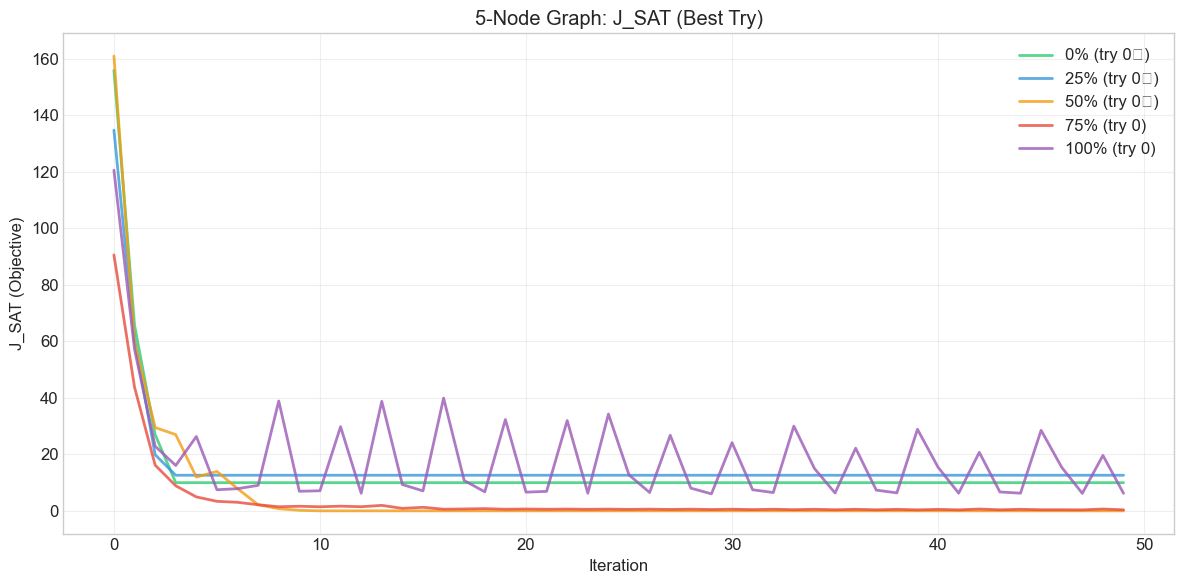

In [14]:
# Plot using the BEST try for each percentage (first to reach 0 unsat, or min unsat)
plot_stat_overlay_best_try(data_5v, "jsat", title="5-Node Graph: J_SAT (Best Try)")

/var/folders/30/nqp_2f3d38g7cj28w_nf1rhm0000gn/T/ipykernel_65846/1841775070.py:145: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '5-Node Graph: Unsatisfied Clauses (Best Try)'}, xlabel='Iteration', ylabel='Unsatisfied Clauses'>)

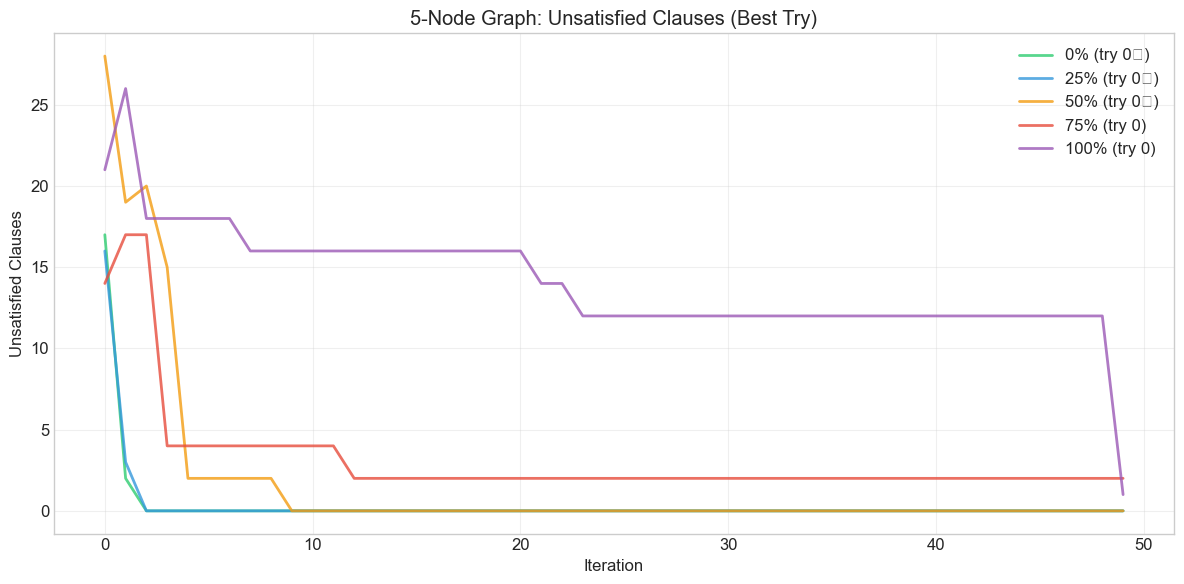

In [15]:
# Unsatisfied clauses - Best try
plot_stat_overlay_best_try(data_5v, "unsat_clauses", title="5-Node Graph: Unsatisfied Clauses (Best Try)")

/var/folders/30/nqp_2f3d38g7cj28w_nf1rhm0000gn/T/ipykernel_65846/1841775070.py:145: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '5-Node Graph: J_SAT (Log Scale)'}, xlabel='Iteration', ylabel='J_SAT (Objective)'>)

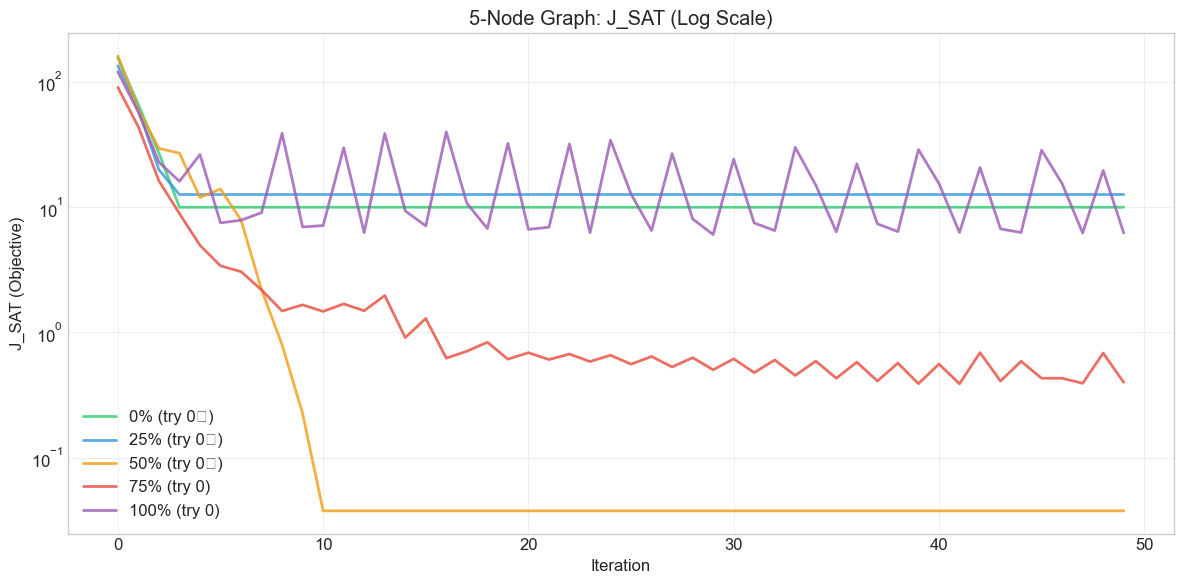

In [16]:
# Plot J_SAT on log scale
plot_stat_overlay_best_try(data_5v, "jsat", title="5-Node Graph: J_SAT (Log Scale)", log_scale=True)

/var/folders/30/nqp_2f3d38g7cj28w_nf1rhm0000gn/T/ipykernel_65846/1841775070.py:206: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'J_SAT (Objective)'}, xlabel='Iteration', ylabel='J_SAT (Objective)'>,
        <Axes: title={'center': 'Unsatisfied Clauses'}, xlabel='Iteration', ylabel='Unsatisfied Clauses'>,
        <Axes: title={'center': 'Gradient Squared'}, xlabel='Iteration', ylabel='Gradient Squared'>,
        <Axes: title={'center': 'Alpha (Step Size)'}, xlabel='Iteration', ylabel='Alpha (Step Size)'>],
       dtype=object))

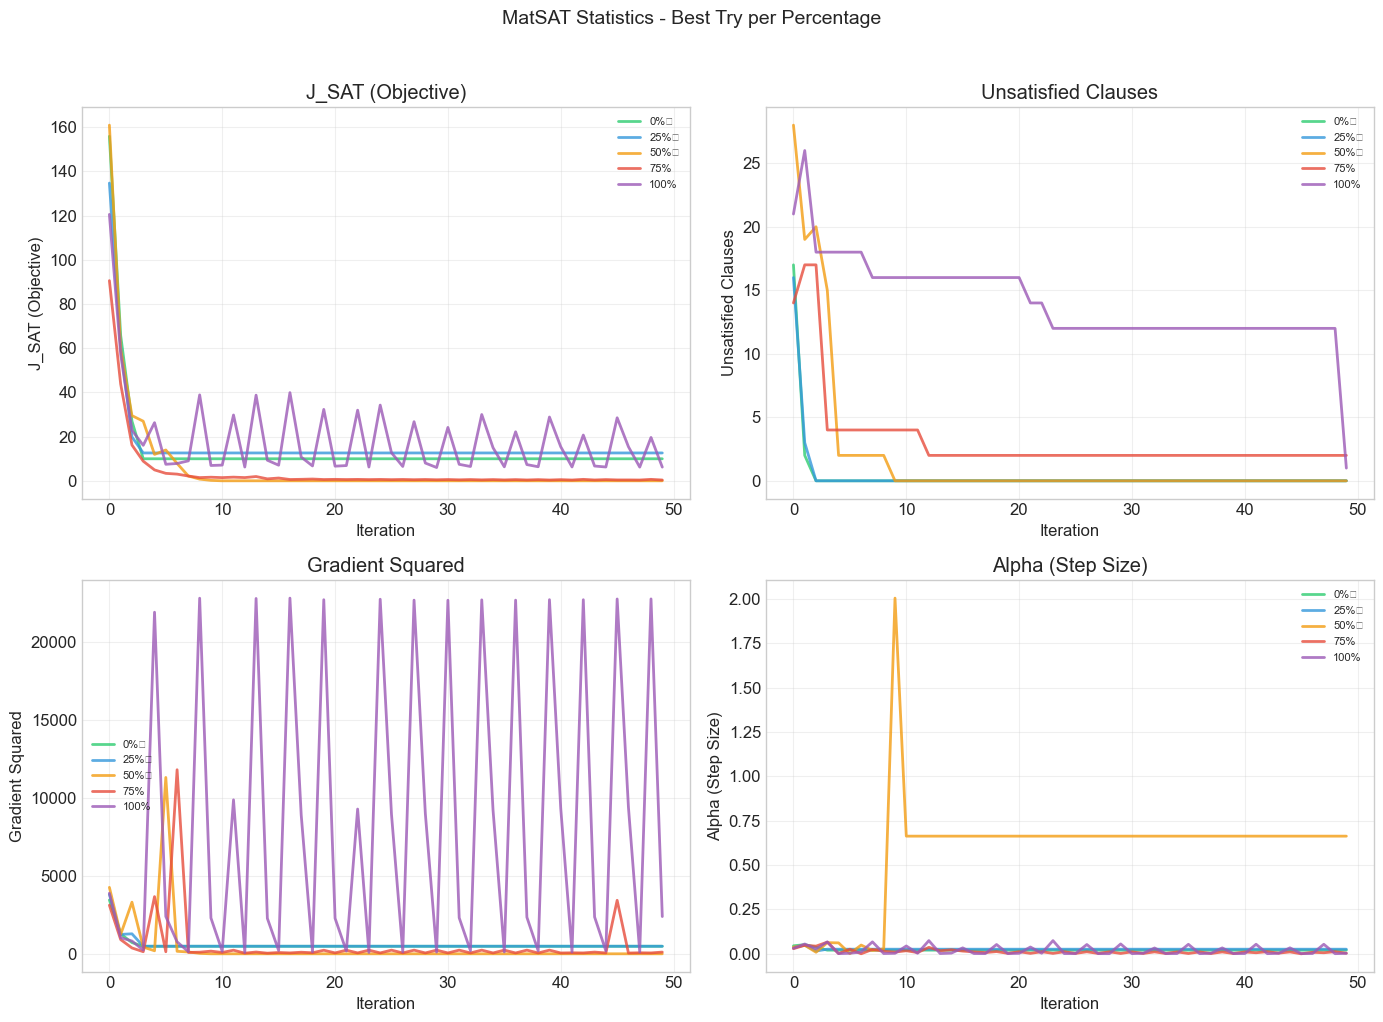

In [17]:
# Multiple stats - Best try for each percentage
plot_multiple_stats_best_try(data_5v, ["jsat", "unsat_clauses", "grad_sq", "alpha"])

---
## Custom Analysis

Load other graph sizes or customize which statistics to plot.

✓ Loaded matsat_prm_5v_6e_blocked_0pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_25pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_50pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_75pct.csv: 250 rows
✓ Loaded matsat_prm_5v_6e_blocked_100pct.csv: 250 rows
✓ Loaded matsat_prm_6v_7e_blocked_0pct.csv: 250 rows
✓ Loaded matsat_prm_6v_7e_blocked_25pct.csv: 250 rows
✓ Loaded matsat_prm_6v_7e_blocked_50pct.csv: 250 rows
✓ Loaded matsat_prm_6v_7e_blocked_75pct.csv: 250 rows
✓ Loaded matsat_prm_6v_7e_blocked_100pct.csv: 250 rows
✓ Loaded matsat_prm_7v_13e_blocked_0pct.csv: 250 rows
✓ Loaded matsat_prm_7v_13e_blocked_25pct.csv: 250 rows
✓ Loaded matsat_prm_7v_13e_blocked_50pct.csv: 250 rows
✓ Loaded matsat_prm_7v_13e_blocked_75pct.csv: 250 rows
✗ Not found: matsat_prm_7v_13e_blocked_100pct.csv


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Gradient Squared vs Iteration (Try 0)'}, xlabel='Iteration', ylabel='Gradient Squared'>)

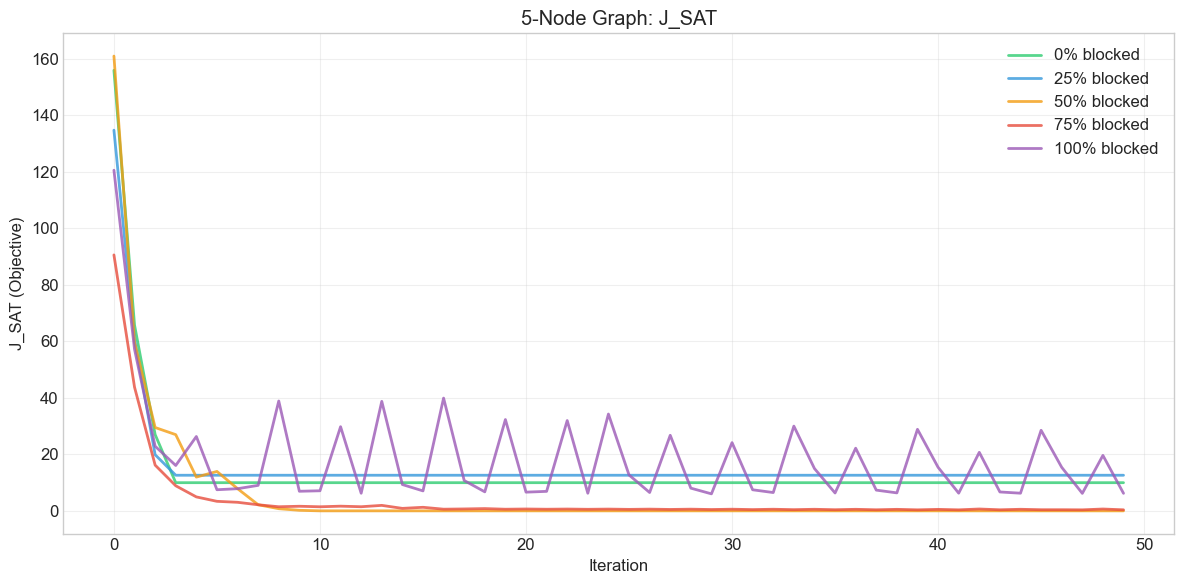

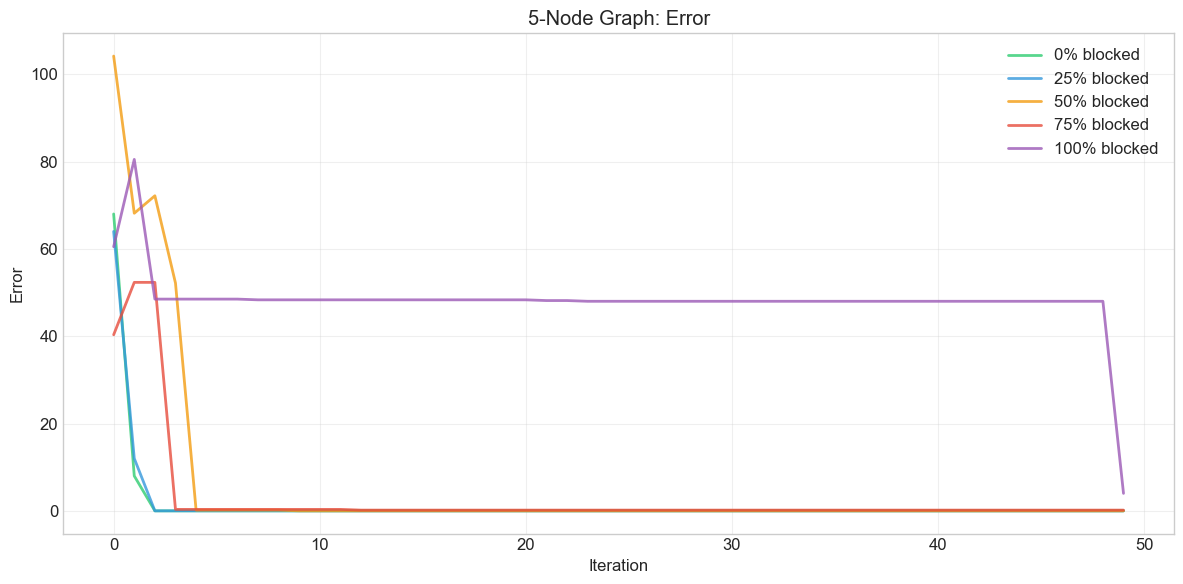

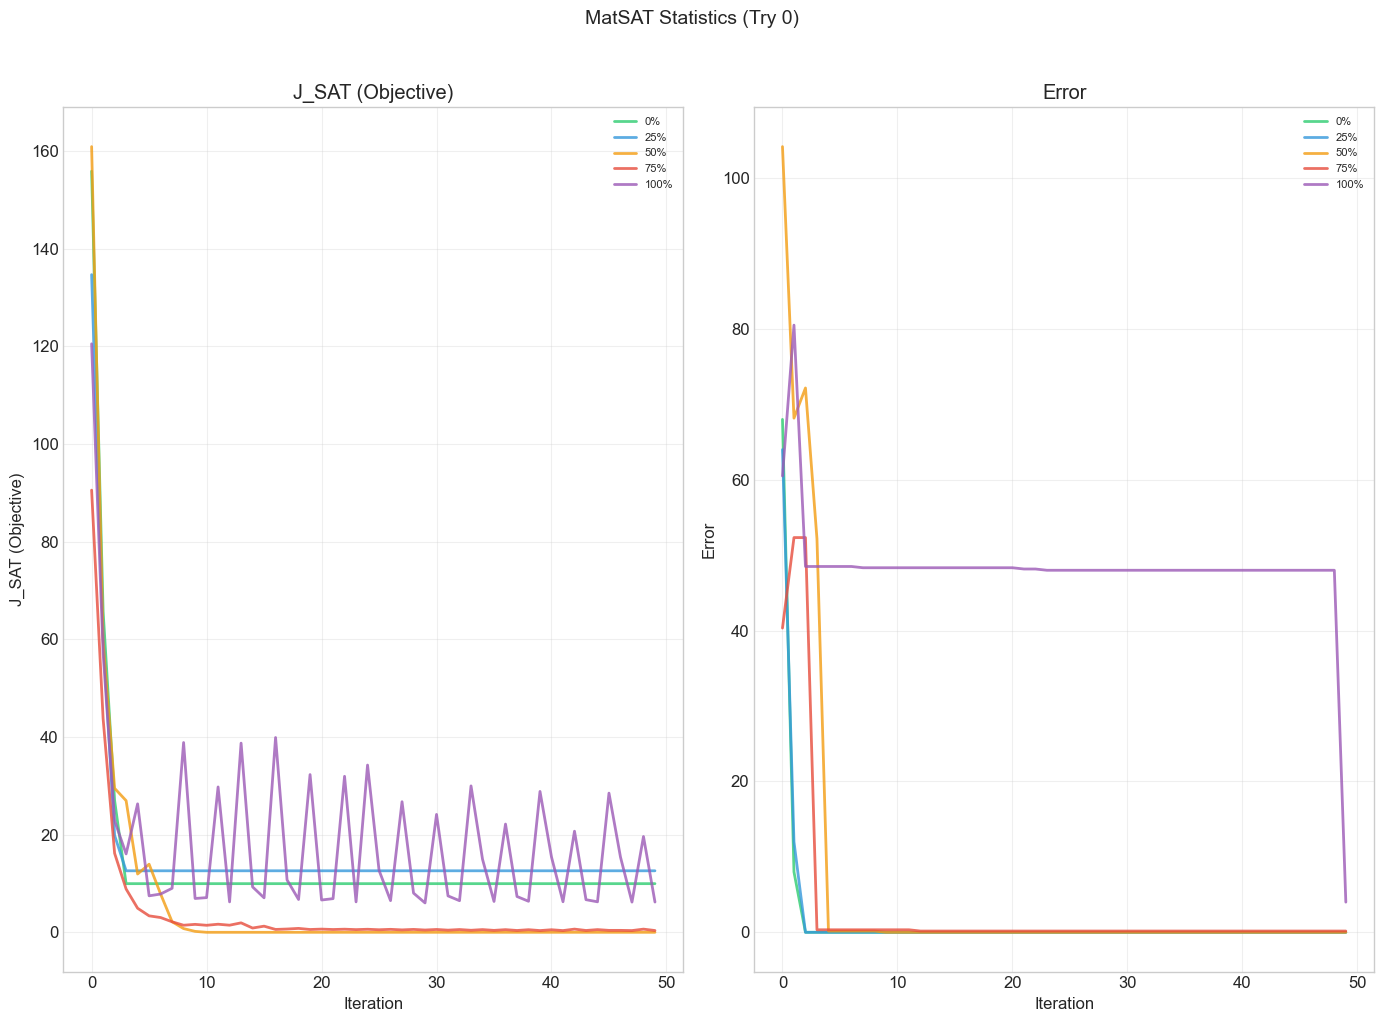

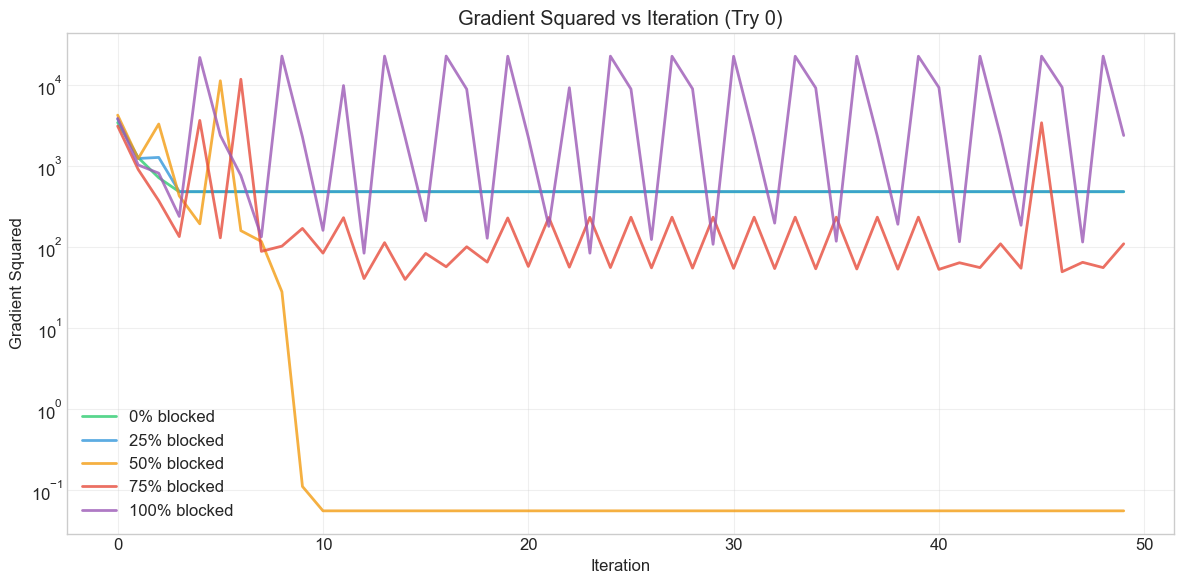

In [22]:
# Load other graph sizes
data_5v = load_prm_csvs("prm_5v_6e_blocked")
data_6v = load_prm_csvs("prm_6v_7e_blocked")
data_7v = load_prm_csvs("prm_7v_13e_blocked")

# Plot specific stats
plot_stat_overlay(data_5v, "jsat", title="5-Node Graph: J_SAT")
plot_stat_overlay(data_5v, "err", title="5-Node Graph: Error")

# Choose which stats to plot
stats_to_plot = ["jsat", "err"]
plot_multiple_stats(data_5v, stats_to_plot)

# Use log scale for large value ranges
plot_stat_overlay(data_5v, "grad_sq", log_scale=True)